# Data Cleaning

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
Discriptive Statistics
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000
Skewnes Value
total_bill    1.133213
tip           1.465451
size          1.447882
dtype: float64
   total_bill       tip      size
0   -0.314066 -1.436993 -0.598961
1   -1.061054 -0.967217  0.452453
2    0.137497  0.362610  0.452453
3    0.437416  0.225291 -0.598961
4    0.

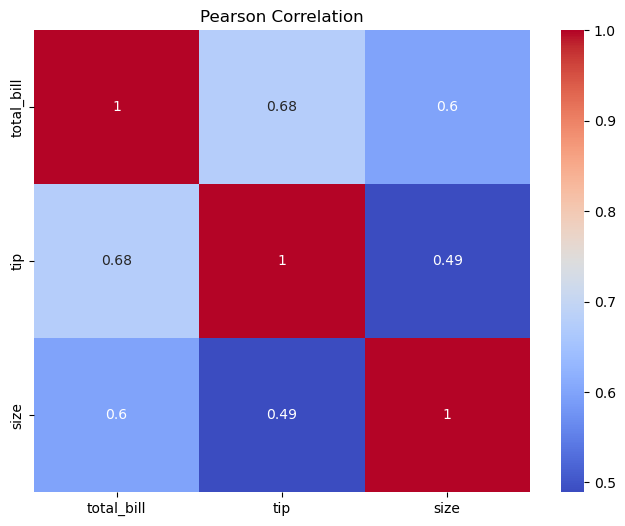

            total_bill       tip      size
total_bill    1.000000  0.678968  0.604791
tip           0.678968  1.000000  0.468268
size          0.604791  0.468268  1.000000


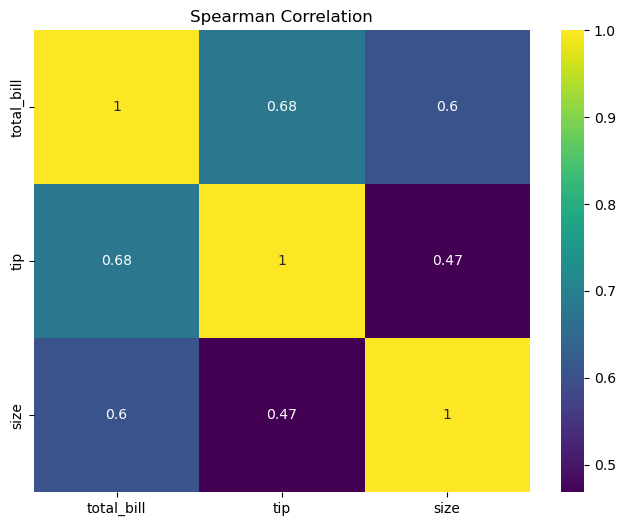

             pearson  spearman
total_bill  1.000000  1.000000
tip         0.675734  0.678968
size        0.598315  0.604791


In [24]:
# 1.import real dataset
import pandas as pd
import numpy as np
# 2.Discriptive Statistics
import seaborn as sns
import matplotlib.pyplot as plt
df=sns.load_dataset('tips')
print(df.head())
print('Discriptive Statistics')
print(df.describe())
# 3.Identifie Skews Distrubution 
print("Skewnes Value")
numeric_cols=df.select_dtypes(include=np.number)
print(numeric_cols.skew())
# 4.Apply Zscore
zscore_df=numeric_cols.copy()
for col in zscore_df.columns:
    zscore_df[col]=(
        zscore_df[col]-zscore_df[col].mean()
    )/zscore_df[col].std()
print(zscore_df.head())
# 5.Pearson Correlation
pearson_corr=numeric_cols.corr(method='pearson')
print(pearson_corr)
plt.figure(figsize=(8,6))
sns.heatmap(
    pearson_corr,
    annot=True,
    cmap='coolwarm'
)
plt.title('Pearson Correlation')
plt.show()
# 6.Spearman  correlation
spearman_corr=numeric_cols.corr(method='spearman')
print(spearman_corr)
plt.figure(figsize=(8,6))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='viridis'
)
plt.title('Spearman Correlation')
plt.show()
# 7.Compare spearman and pearson
comparison=pd.DataFrame({
    'pearson':pearson_corr['total_bill'],
    'spearman':spearman_corr['total_bill']
})
print(comparison)

In [57]:
import pandas as pd
import seaborn as sns
df=sns.load_dataset('tips')
print(df.head())
print(df.shape)
df.info()
#Create Problems
df.loc[0,'embark_town']='southampton'
df.loc[1,'embark_town']='SOUTHAMPTON'
df.loc[2,'embark_town']='Southampton'
print(df['embark_town'].unique())
#UNIQUE VALUES
df['embark_town']=df['embark_town'].str.title()
print(df['embark_town'].unique())
#ISNULl
print(df['embark_town'].isnull().sum())
#Fillna
df['embark_town']=df['embark_town'].fillna('Kingstown')
print(df['embark_town'].unique())
# Create Find Duplicate Rows
duplicate_rows=df.iloc[:5]
df_dup=pd.concat([df,duplicate_rows])
print(df_dup.shape)
#Find duplicate
print(df_dup.duplicated().sum())
#View duplicate rows
df_dup[df_dup.duplicated()]
#Remove duplicate
df_dup=df_dup.drop_duplicates()
print(df_dup.duplicated().sum())

#Create type
df.loc[0,'embark_town']='SOUTHAMPTON'
df.loc[1,'embark_town']='Southamton'
print(df['embark_town'].value_counts())
# Fix types
df['embark_town']=df['embark_town'].replace({
    'Southamton':'Southampton',
    'Southhampton':'Southampton'
})
#Verify
print(df['embark_town'].value_counts())
#Detect Possible Types
print(sorted(df['embark_town'].dropna().unique()))

#Unit measures - measure units value in the data
#Create data
df.loc[0,'age']=240
df.loc[1,'age']=300
#Detect Unsual Values
df['age'].describe()
#Fix unit match
#convert months to years
df.loc[df['age']>120,'age']=(
    df.loc[df['age']>120,'age']/12
)
#Verify
df['age'].describe()

#Wrong Category Labels
df['tip_label']=df['tip'].map({
    0:'No',
    1:'Yes'
})
print(df.head())

#Redundant Column
#check
df.isnull().mean()
#Remove
df.drop(columns=['tip'],inplace=True)
df.head()

#Handle NULL values
#Method 1:Mean Inputation
#Replace missing values with the average values
df['age']=df['age'].fillna(df['age'].mean())
df.head(20)
#Method 2:Median Inputation
#Replace missing values with the middle values
df['age']=df['age'].fillna(df['age'].median())
df.head(20)
#Method 3 : Mode imputation
#replace missing values with the average value
df["age"]=df["age"].fillna(df["age"].mode())
#Method 4: Forward Fill(FFill)
#Use the previous value to fill missing data
#Before Imputation
print(df["day"].isnull().sum())

 #check age skew()
 #if skew() high - Median
 # id data is nearly normal - Mean
#Apply Forward fill
df['day_ffill'] = df['day'].ffill()
#Check missing values
print(df['day_ffill'].isnull().sum())
#Method 5: KNN Imputation
#K-Nearest Neighbours(KNN) Imputation fills missing values using information from similar rows
#Instead of using a single value(mean/median),it finds the K most similar records and uses their values
import pandas as pd
import numpy as np
data={
    "age":[22,25,np.nan,24,23],
    "fare":[7.25,8.05,7.90,8.00,7.50]
}
df=pd.DataFrame(data)
print(df)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
(244, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
['southampton' 'SOUTHAMPTON' 'Southampton' nan]
['Southampton' nan]
241
['Southampton' 'Kingstown']
(249, 8)
6
0
embark_to

## Backward fill
### df.final(method='bfill',inplace=True)
## or
### df.bfill(inplace=True)

## Encoding
### *ml models work with numbers not text
### *using binary values in encoding to change the values into number to meachine
## Types:
### 1.Label Encoding(ordinal data) - Assigns a number to each category - Small,Medium,Large
### 2.Nominal Category - 

In [72]:
#One-Hot encoding - Create a separate binary cloumn for each category
# Target Encoding - Replace categories with the average value of the target variable
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder # import label encoder from skyket learn

# Load tips dataset
df=sns.load_dataset('tips')
print(df)
#Label Encoding
le=LabelEncoder()
df['sex_encoded']=le.fit_transform(
    df['sex']
)
#One-Hot Encoding
df=pd.get_dummies(
    df,
    columns=['day']
)
#Target Encoding
target_map=df.groupby(
    'size'
)['size'].mean()
df['size_target']=(
    df['size'].map(target_map)
)
print(df.head())


     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]
   total_bill   tip     sex smoker    time  size  sex_encoded  day_Thur  \
0       16.99  1.01  Female     No  Dinner     2            0     False   
1       10.34  1.66    Male     No  Dinner     3            1     False   
2       21.01  3.50    Male     No  Dinner     3            1     F

# Feature Scaling
### Feature Scaling transform numerical feature to a similar scale

# MinMax Scaler
### Scale values between 0 and 1

# Standard Scaler
### Centers data around mean=0 and standard deviation =1
# RabustScaler
### Uses median and IQR insted of mean and Standard Deviation


In [79]:
from sklearn.preprocessing import LabelEncoder
scaler = MinMaxScaler()
df[['tip_minmax','size_minmax']]=scaler.fit_transform(
    df[['tip','size']]
)
df[['tip_minmax','size_minmax']].head()

,tip_minmax,size_minmax
0,0.001111,0.2
1,0.073333,0.4
2,0.277778,0.4
3,0.256667,0.2
4,0.290000,0.6


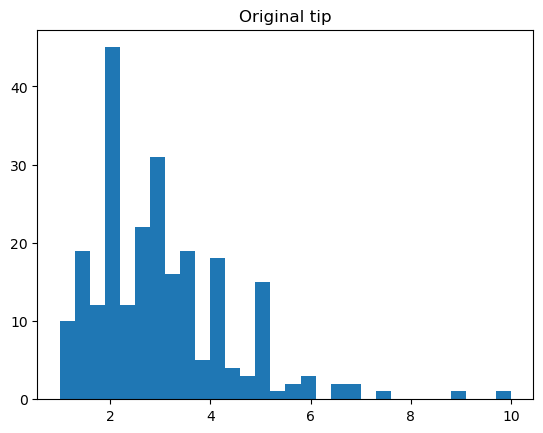

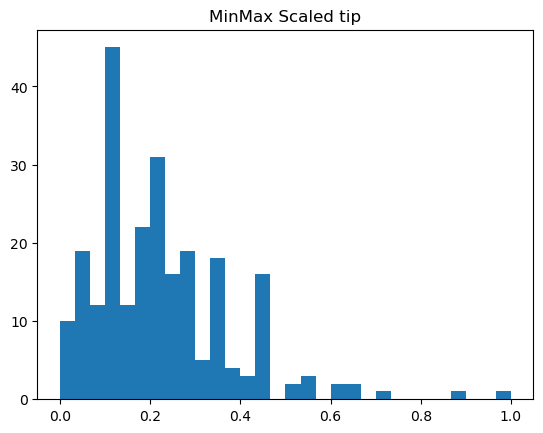

In [80]:
import matplotlib.pyplot as plt
plt.hist(df['tip'].dropna(), bins=30)
plt.title('Original Tip')
plt.show()
plt.hist(df['tip_minmax'].dropna(), bins=30)
plt.title('MinMax Scaled Tip')
plt.show()

In [81]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['tip_std','size_std']]=scaler.fit_transform(
    df[['tip','size']]
)
df[['tip_std','size_std']].head()

,tip_std,size_std
0,-1.439947,-0.600193
1,-0.969205,0.453383
2,0.363356,0.453383
3,0.225754,-0.600193
4,0.443020,1.506958


In [83]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df[['tip_robust','size_robust']]=scaler.fit_transform(
    df[['tip','size']]
)
df[['tip_robust','size_robust']].head()

,tip_robust,size_robust
0,-1.2096,0.0
1,-0.7936,1.0
2,0.3840,1.0
3,0.2624,0.0
4,0.4544,2.0
